In [100]:
import os
import sys
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float64)

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [101]:
model_u, model_k = build_models(
    device=device,
    hidden_layers=4,
    hidden_units=50,
    activation=nn.Tanh(),
) 

(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
) = generate_dataset_inf(
    alpha=0.5,
    beta=5.0,
    epsilon=1.0,
    device=device,
)

In [102]:
history = train_dual_network(
    model_u,
    model_k,
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    adam_lr=1e-3,
    adam_iters=1000,
    lbfgs_iters=2000,
    adaptive_weights=True,
    verbose=True,
)


Training with Adam
Adam     0 | Total=5.231e+01 | ObsU=2.046e-01 | ObsK=6.377e-01 | PDE=5.147e+01
Updated weights -> λu=1.00, λk=1.00, λpde=1.10
Adam   100 | Total=1.551e+01 | ObsU=3.417e-02 | ObsK=1.068e+00 | PDE=1.310e+01
Updated weights -> λu=1.00, λk=1.01, λpde=1.10
Adam   200 | Total=1.120e+00 | ObsU=2.504e-02 | ObsK=6.813e-02 | PDE=9.326e-01
Updated weights -> λu=1.00, λk=1.00, λpde=1.10
Adam   300 | Total=4.477e-01 | ObsU=1.458e-02 | ObsK=2.607e-02 | PDE=3.700e-01
Updated weights -> λu=1.00, λk=1.00, λpde=1.10
Adam   400 | Total=2.490e-01 | ObsU=4.540e-03 | ObsK=1.404e-02 | PDE=2.094e-01
Updated weights -> λu=1.00, λk=1.00, λpde=1.10
Adam   500 | Total=1.550e-01 | ObsU=3.897e-03 | ObsK=9.641e-03 | PDE=1.285e-01
Updated weights -> λu=1.00, λk=1.00, λpde=1.10
Adam   600 | Total=8.558e-02 | ObsU=2.139e-03 | ObsK=6.625e-03 | PDE=6.981e-02
Updated weights -> λu=1.00, λk=1.01, λpde=1.10
Adam   700 | Total=9.727e-02 | ObsU=1.227e-03 | ObsK=5.577e-03 | PDE=8.221e-02
Updated weights -> 

KeyboardInterrupt: 

Relative L2 error (u): 2.893e-02
Relative L2 error (k): 3.721e-03


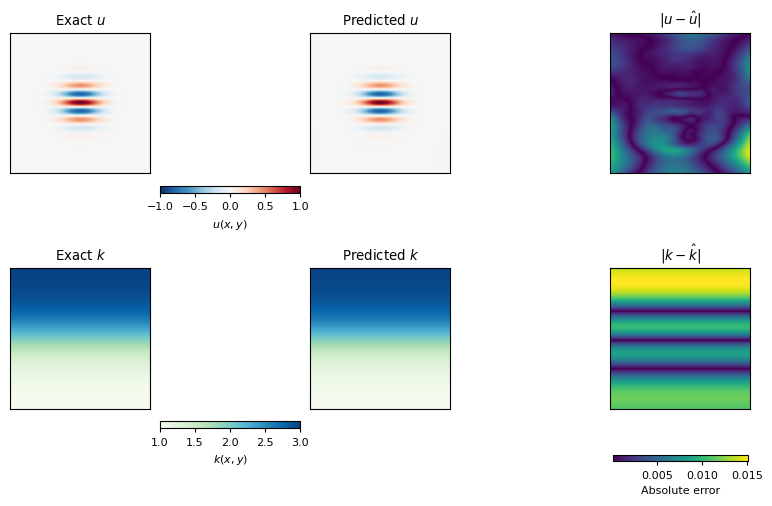

Results saved to: results/infinite_problem_results_20260715_120920.txt


In [98]:
err_u, err_k = evaluate_model_inf(
    model_u,
    model_k,
    analytical_solution_inf,
    coefficient_inf,
    device=device,
    save_results=True,
    verbose=True,
    plot=True
)

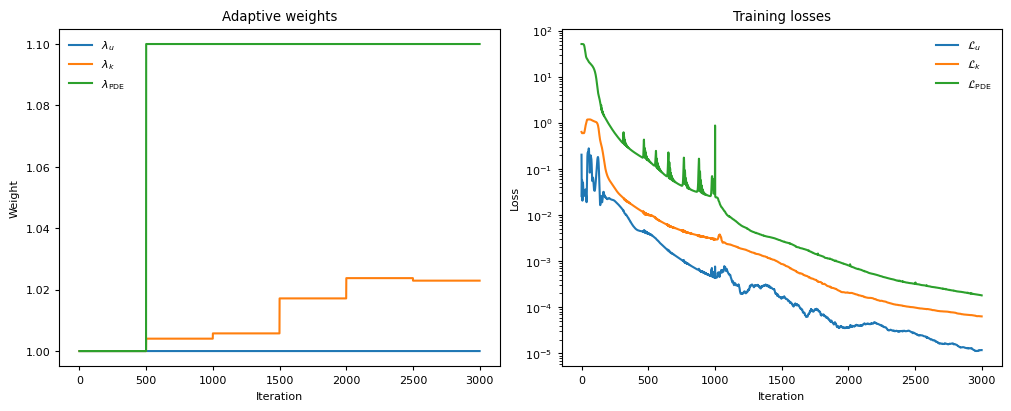

In [99]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

# =====================================================
# Adaptive weights
# =====================================================

ax[0].plot(history["lambda_u"], label=r"$\lambda_u$")
ax[0].plot(history["lambda_k"], label=r"$\lambda_k$")
ax[0].plot(history["lambda_pde"], label=r"$\lambda_{\mathrm{PDE}}$")

ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Weight")
ax[0].set_title("Adaptive weights")
ax[0].legend(frameon=False)

# =====================================================
# Loss history
# =====================================================

ax[1].plot(history["u"], label=r"$\mathcal{L}_u$")
ax[1].plot(history["k"], label=r"$\mathcal{L}_k$")
ax[1].plot(history["pde"], label=r"$\mathcal{L}_{\mathrm{PDE}}$")

ax[1].set_yscale("log")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Loss")
ax[1].set_title("Training losses")
ax[1].legend(frameon=False)

plt.savefig(
    "figures/adaptive_weights_and_losses.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [20]:
err_u, err_k = run_experiment_inf(
    hidden_layers=4,
    hidden_units=50,
    adam_lr=1e-3,
    n_obs_u=100,
    n_obs_k=100,
    n_pde=10000,
    device=device,
)

score = 0.5 * (err_u + err_k)

Relative L2 error (u): 2.358e-02
Relative L2 error (k): 2.340e-03
